In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle
import json

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

# Load data
df = pd.read_csv("../data/processed/features_toba.csv", parse_dates=["date"])
balige = df[df["location"] == "Balige (Tobasa)"].copy()
balige = balige.sort_values("date").reset_index(drop=True)

# Prophet butuh kolom bernama "ds" dan "y"
prophet_df = balige[["date", "temperature_2m_max"]].rename(
    columns={"date": "ds", "temperature_2m_max": "y"}
)

print(f"Data siap: {len(prophet_df)} baris")
print(f"Periode  : {prophet_df['ds'].min().date()} s/d {prophet_df['ds'].max().date()}")
prophet_df.head(3)

Data siap: 3624 baris
Periode  : 2015-01-30 s/d 2024-12-31


,ds,y
0,2015-01-30,28.1
1,2015-01-31,27.5
2,2015-02-01,27.3


In [2]:
split_idx = int(len(prophet_df) * 0.8)
train = prophet_df.iloc[:split_idx].copy()
test  = prophet_df.iloc[split_idx:].copy()

print(f"Train: {len(train)} hari ({train['ds'].min().date()} s/d {train['ds'].max().date()})")
print(f"Test : {len(test)} hari ({test['ds'].min().date()} s/d {test['ds'].max().date()})")

Train: 2899 hari (2015-01-30 s/d 2023-01-06)
Test : 725 hari (2023-01-07 s/d 2024-12-31)


In [3]:
print("Training Prophet model")

model = Prophet(
    seasonality_mode="additive",   # Pola musiman ditambahkan ke tren
    yearly_seasonality=True,        # Tangkap pola tahunan (musim hujan/kemarau)
    weekly_seasonality=True,        # Tangkap pola mingguan
    daily_seasonality=False,        # Data harian, tidak perlu
    changepoint_prior_scale=0.05,   # Fleksibilitas tren (0.05 = cukup fleksibel)
    seasonality_prior_scale=10,     # Kekuatan pola musiman
    interval_width=0.80             # 80% confidence interval
)

# Tambah seasonality bulanan secara eksplisit
model.add_seasonality(name="monthly", period=30.5, fourier_order=5)

# Fit model
model.fit(train)
print("Training selesai!")

Training Prophet model


22:37:00 - cmdstanpy - INFO - Chain [1] start processing
22:37:04 - cmdstanpy - INFO - Chain [1] done processing


Training selesai!


In [4]:
# Buat dataframe future untuk periode test
future = model.make_future_dataframe(periods=len(test), freq="D")
forecast = model.predict(future)

# Ambil prediksi hanya untuk periode test
forecast_test = forecast[forecast["ds"].isin(test["ds"])].copy()

print(f"Prediksi {len(forecast_test)} hari selesai")
print(forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(5).to_string(index=False))

Prediksi 725 hari selesai
        ds      yhat  yhat_lower  yhat_upper
2023-01-07 28.816828   28.063963   29.540851
2023-01-08 28.821798   28.073024   29.626968
2023-01-09 28.803068   28.004765   29.577335
2023-01-10 28.781106   28.001046   29.525938
2023-01-11 28.792125   27.979379   29.546613


In [5]:
actual    = test["y"].values
predicted = forecast_test["yhat"].values

def evaluate(actual, predicted, model_name="Model"):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = 1 - np.sum((actual - predicted)**2) / np.sum((actual - actual.mean())**2)

    print(f" Evaluasi {model_name} ")
    print(f"  MAE  : {mae:.3f}°C")
    print(f"  RMSE : {rmse:.3f}°C")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
    return {"model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

prophet_metrics = evaluate(actual, predicted, "Prophet")

 Evaluasi Prophet 
  MAE  : 0.726°C
  RMSE : 0.884°C
  MAPE : 2.56%
  R²   : 0.3074


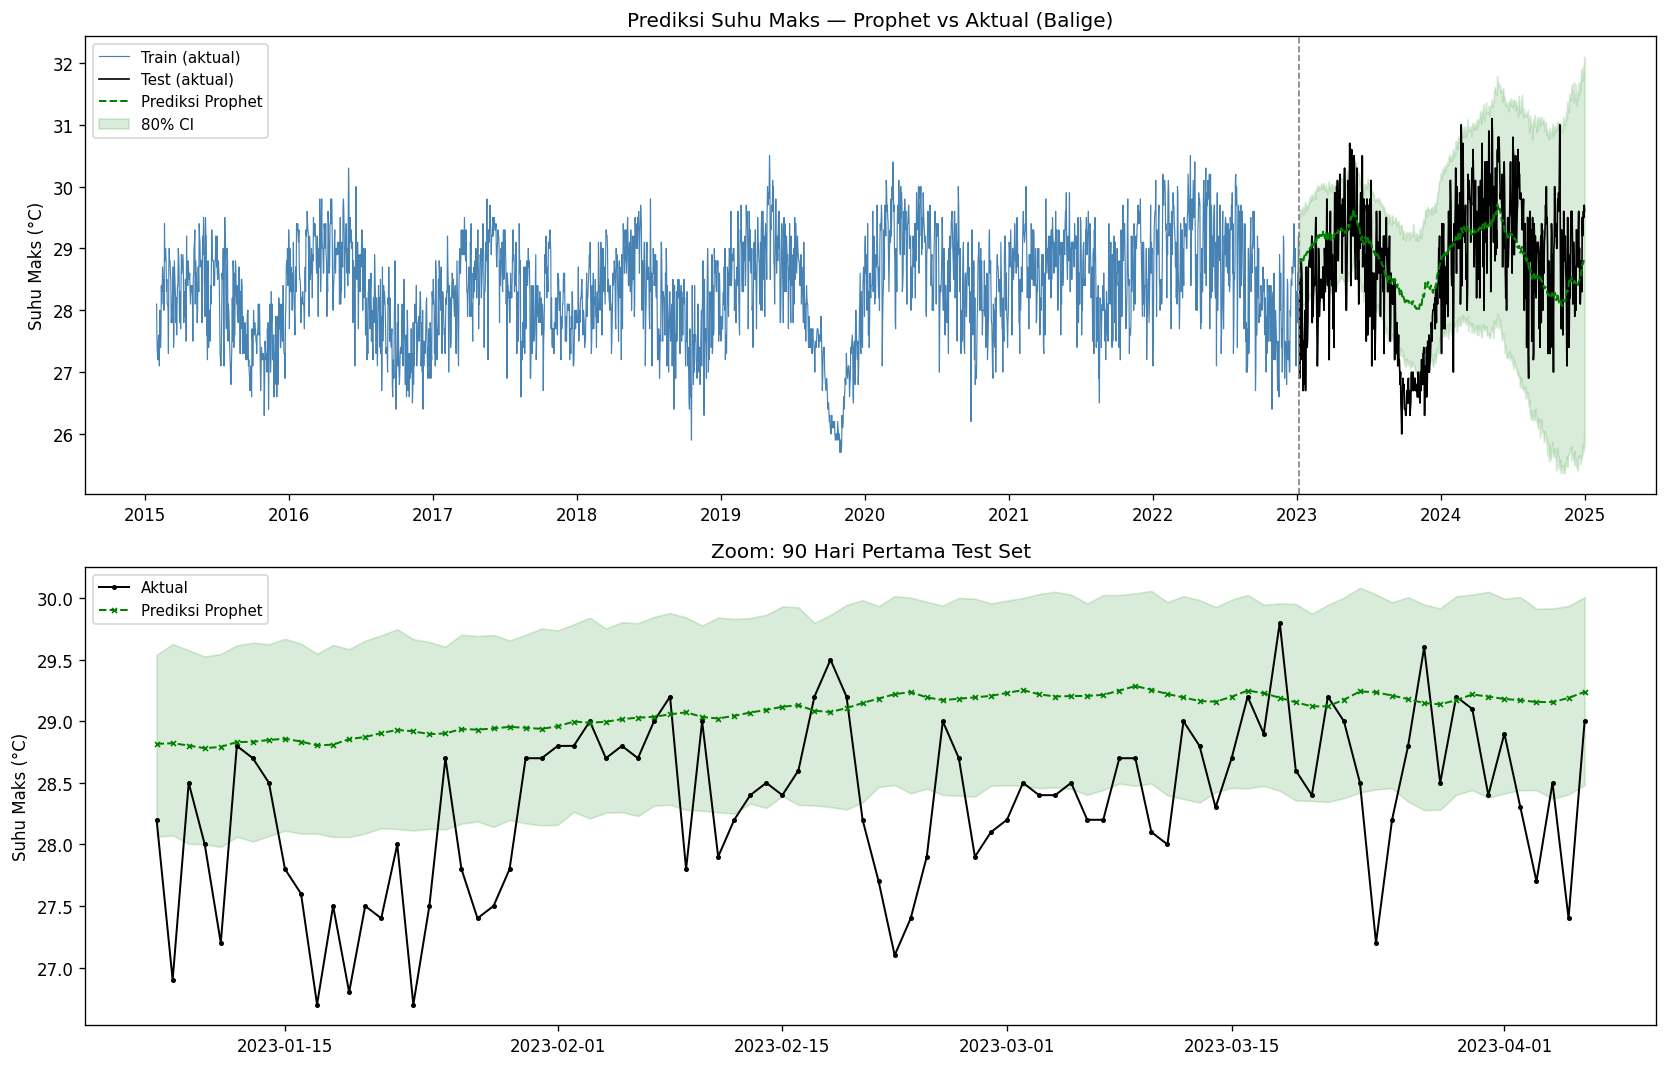

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Plot 1: full timeline
axes[0].plot(train["ds"], train["y"],
             color="steelblue", linewidth=0.7, label="Train (aktual)")
axes[0].plot(test["ds"], test["y"],
             color="black", linewidth=1, label="Test (aktual)")
axes[0].plot(forecast_test["ds"], forecast_test["yhat"],
             color="green", linewidth=1.2, linestyle="--", label="Prediksi Prophet")
axes[0].fill_between(forecast_test["ds"],
                     forecast_test["yhat_lower"],
                     forecast_test["yhat_upper"],
                     color="green", alpha=0.15, label="80% CI")
axes[0].axvline(test["ds"].iloc[0], color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Prediksi Suhu Maks — Prophet vs Aktual (Balige)")
axes[0].set_ylabel("Suhu Maks (°C)")
axes[0].legend(fontsize=9)

# Plot 2: zoom 90 hari pertama test
zoom = test.head(90)
zoom_forecast = forecast_test.head(90)
axes[1].plot(zoom["ds"], zoom["y"],
             color="black", linewidth=1.2, marker="o", markersize=2, label="Aktual")
axes[1].plot(zoom_forecast["ds"], zoom_forecast["yhat"],
             color="green", linewidth=1.2, linestyle="--", marker="x",
             markersize=3, label="Prediksi Prophet")
axes[1].fill_between(zoom_forecast["ds"],
                     zoom_forecast["yhat_lower"],
                     zoom_forecast["yhat_upper"],
                     color="green", alpha=0.15)
axes[1].set_title("Zoom: 90 Hari Pertama Test Set")
axes[1].set_ylabel("Suhu Maks (°C)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/08_prophet_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

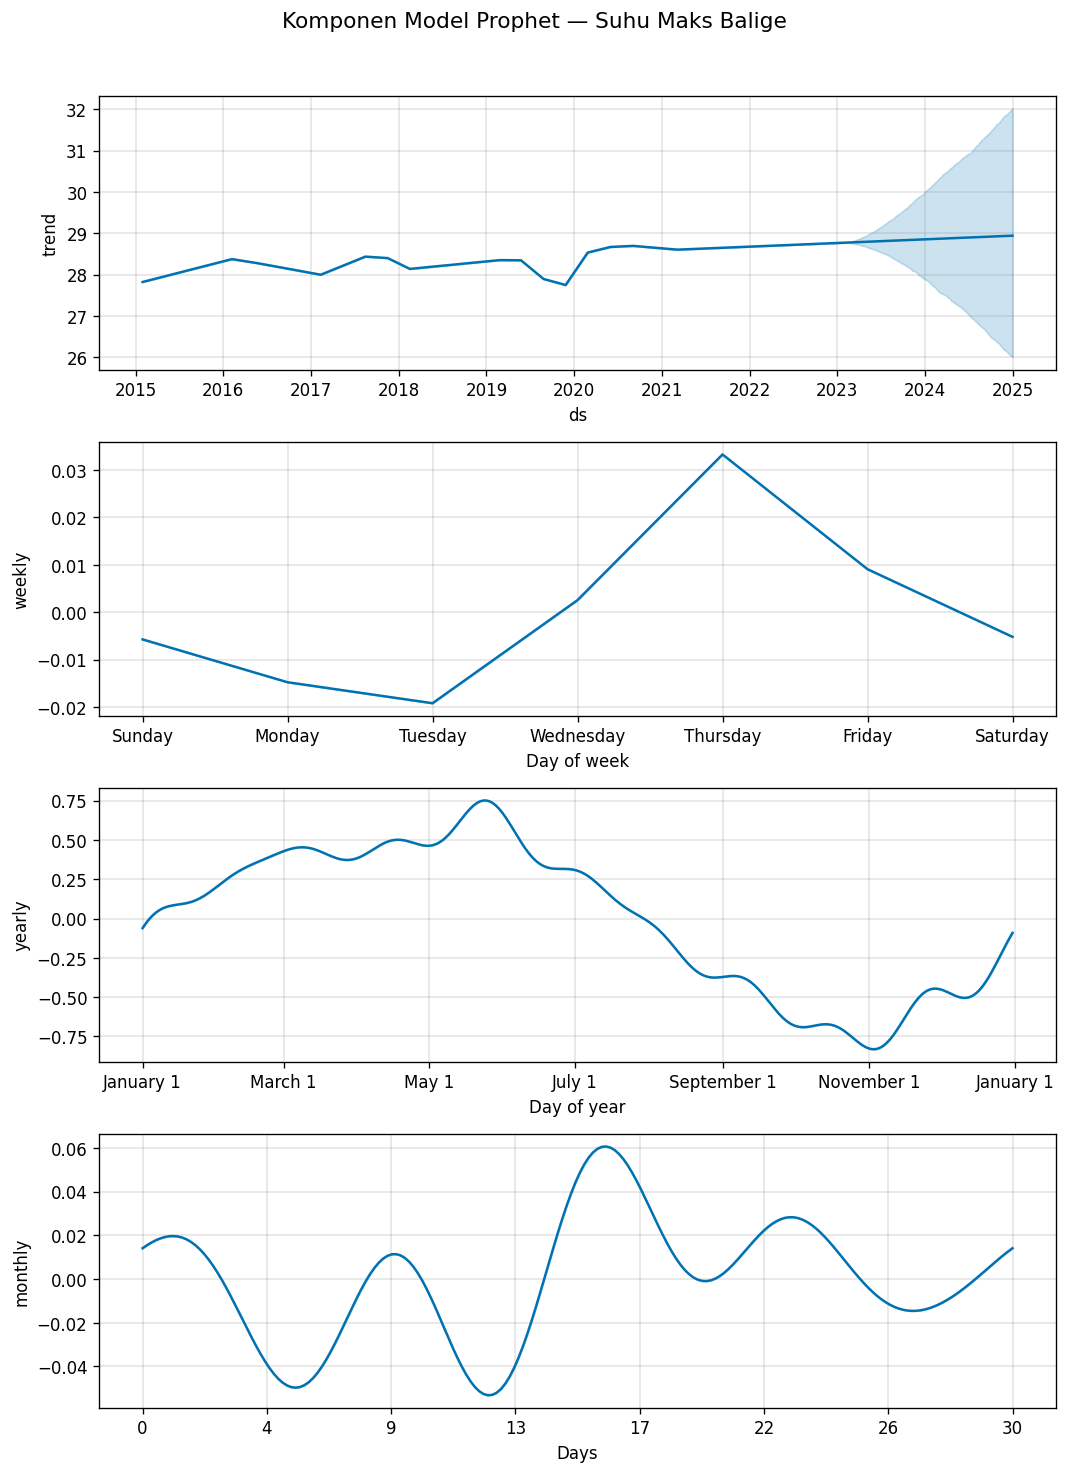

Chart komponen tersimpan


In [7]:
# Prophet bisa breakdown tren, musiman tahunan, mingguan, dan bulanan
fig = model.plot_components(forecast)
fig.suptitle("Komponen Model Prophet — Suhu Maks Balige", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/09_prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart komponen tersimpan")

In [8]:
# Simpan model Prophet
model_path = "../models/prophet_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model disimpan: {model_path}")

# Update metrics comparison
metrics_path = "../models/metrics_comparison.json"
with open(metrics_path, "r") as f:
    metrics_data = json.load(f)

metrics_data["Prophet"] = prophet_metrics

with open(metrics_path, "w") as f:
    json.dump(metrics_data, f, indent=2)

# Perbandingan SARIMA vs Prophet
print(f"  PERBANDINGAN: SARIMA vs Prophet")
print(f"{'Metrik':<10} {'SARIMA':>12} {'Prophet':>12} {'Winner':>10}")

sarima = metrics_data["SARIMA"]
prophet_m = metrics_data["Prophet"]

for metric in ["MAE", "RMSE", "MAPE"]:
    winner = "Prophet " if prophet_m[metric] < sarima[metric] else "SARIMA "
    print(f"{metric:<10} {sarima[metric]:>12.3f} {prophet_m[metric]:>12.3f} {winner:>10}")

r2_winner = "Prophet " if prophet_m["R2"] > sarima["R2"] else "SARIMA "
print(f"{'R²':<10} {sarima['R2']:>12.4f} {prophet_m['R2']:>12.4f} {r2_winner:>10}")

Model disimpan: ../models/prophet_model.pkl
  PERBANDINGAN: SARIMA vs Prophet
Metrik           SARIMA      Prophet     Winner
MAE               0.933        0.726   Prophet 
RMSE              1.112        0.884   Prophet 
MAPE              3.238        2.558   Prophet 
R²              -0.0978       0.3074   Prophet 
